In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
API_URL = "https://raw.githubusercontent.com/ankitshishodiya83/student-scores-api/refs/heads/main/students.json"

response = requests.get(API_URL, timeout=10)
response.raise_for_status()      # stops with an error if the request failed
data = response.json()

# Some APIs wrap the list, e.g. {"students": [...]}
if isinstance(data, dict):
    data = data["students"]

print(f"Fetched {len(data)} records")

Fetched 7 records


In [3]:
df = pd.DataFrame(data)
df["score"] = pd.to_numeric(df["score"], errors="coerce")   # bad values become NaN
df = df.dropna(subset=["name", "score"])                    # drop incomplete rows
df

,name,score
0,Alice,88
1,Bob,72
2,Carla,95
3,Dev,64
4,Emma,81
5,Farid,58
6,Grace,90


In [4]:
average = df["score"].mean()

print(f"Average score: {average:.2f}")
print(f"Highest: {df.loc[df['score'].idxmax(), 'name']} ({df['score'].max():.0f})")
print(f"Lowest:  {df.loc[df['score'].idxmin(), 'name']} ({df['score'].min():.0f})")
print(f"Students above average: {(df['score'] > average).sum()} of {len(df)}")

Average score: 78.29
Highest: Carla (95)
Lowest:  Farid (58)
Students above average: 4 of 7


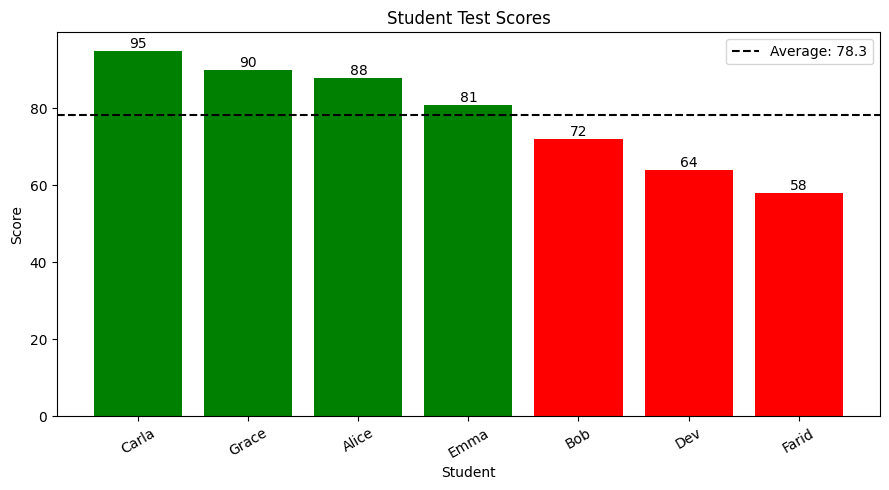

In [5]:
df_sorted = df.sort_values("score", ascending=False)
colors = ["green" if s >= average else "red" for s in df_sorted["score"]]

plt.figure(figsize=(9, 5))
bars = plt.bar(df_sorted["name"], df_sorted["score"], color=colors)
plt.bar_label(bars)                                   # numbers on top of bars
plt.axhline(average, color="black", linestyle="--", label=f"Average: {average:.1f}")

plt.title("Student Test Scores")
plt.xlabel("Student")
plt.ylabel("Score")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()